## Data Imports

In [4]:
import pandas as pd
import os

In [5]:
df = pd.read_csv("ML_dataset2.csv")
df.head()

,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032,24.18333,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Algeria,2002,61.0,20.755,0.103333,NaN,-1.000000,0.115583,1835.018,23.87500,85.04,1.330395,354.226905,1751.911234,53.735272,31.96875,210.0
2,Algeria,2003,99.0,23.075,0.107500,0.000121,2.333333,0.120667,2119.552,23.85833,87.52,1.329615,349.548223,1793.094603,55.305819,32.48746,158.0
3,Algeria,2004,94.0,21.668,0.107500,0.000125,3.000000,0.122333,2149.398,23.51667,90.01,1.396440,344.700914,2116.689481,56.876366,32.96862,96.0
4,Algeria,2005,73.0,21.193,0.105833,0.000080,-6.500000,0.120083,1926.585,23.88333,92.49,1.463309,339.693600,2627.289243,58.446912,33.41618,78.0


## Initial Data Cleaning

In [6]:
df.columns = df.columns.str.strip()

df["Country"] = df["Country"].str.replace(
    "Eswatini (formerly Swaziland)", "Eswatini"
)

df["Water Stress"] = (
    df["Water Stress"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
    .replace(["", "nan", "None"], pd.NA)
)

df = df.dropna(how="all")


## EDA

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

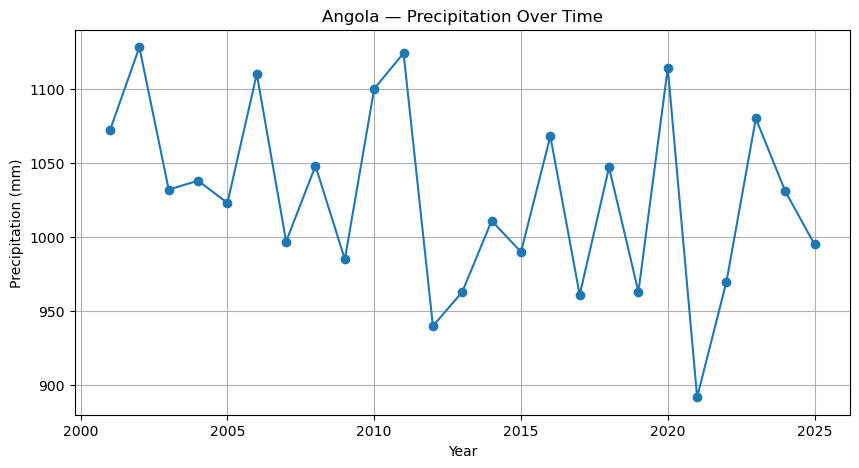

In [8]:
angola = df[df["Country"]=="Angola"]
plt.figure(figsize=(10,5))
plt.plot(angola["Year"], angola["Precipitation"], marker="o")
plt.title("Angola — Precipitation Over Time")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()

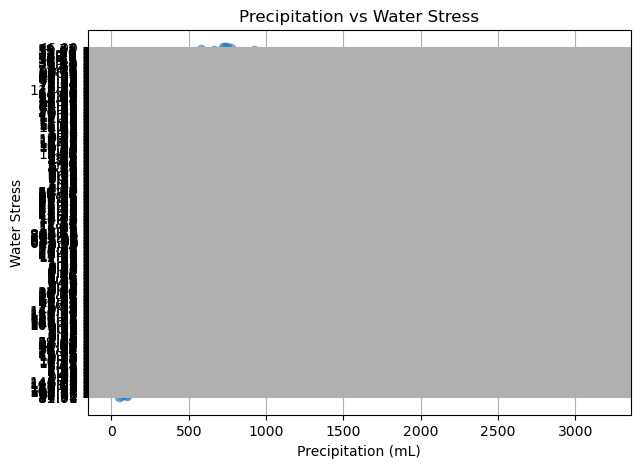

In [9]:
scatter_df = df[["Precipitation", "Water Stress"]].dropna()
plt.figure(figsize=(7,5))
plt.scatter(scatter_df["Precipitation"], scatter_df["Water Stress"], alpha=0.5)
plt.title("Precipitation vs Water Stress")
plt.xlabel("Precipitation (mL)")
plt.ylabel("Water Stress")
plt.grid(True)
plt.show()

C:\Users\sidne\AppData\Local\Temp\ipykernel_8596\176605096.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
C:\Users\sidne\AppData\Local\Temp\ipykernel_8596\176605096.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")


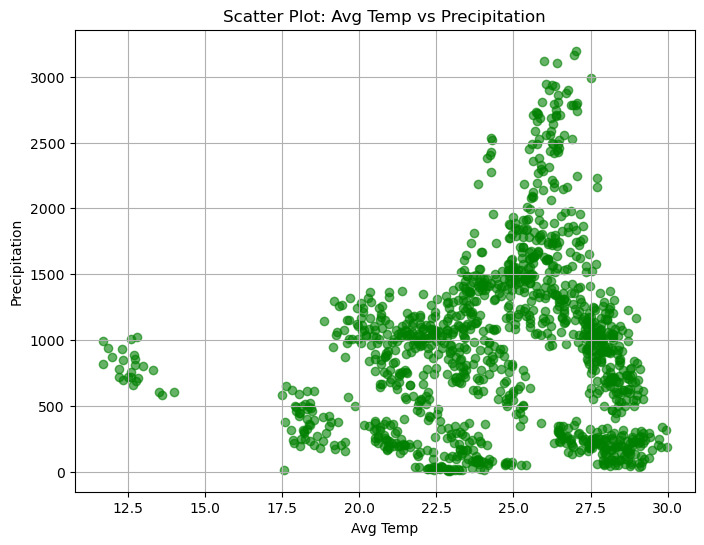

In [10]:
scatter_df = df.dropna(subset=["Avg Temp", "Precipitation"])

scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")

plt.figure(figsize=(8,6))
plt.scatter(scatter_df["Avg Temp"], scatter_df["Precipitation"], c='green', alpha=0.6)
plt.xlabel("Avg Temp")
plt.ylabel("Precipitation")
plt.title("Scatter Plot: Avg Temp vs Precipitation")
plt.grid(True)
plt.show()

## Split for Final Test

In [11]:
FINAL_TEST_YEAR = 2021

test_df = df[df["Year"] == FINAL_TEST_YEAR].copy()
train_df = df[df["Year"] < FINAL_TEST_YEAR].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1080, 17)
Test shape: (54, 17)


## Further Cleaning

In [12]:
numeric_cols = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence", "Water Stress"
]

def clean_numeric(df, cols):
    for col in cols:
        df[col] = (
            df[col].astype(str)
                   .str.replace(",", "", regex=False)
                   .str.replace("*", "", regex=False)
                   .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

train_df = clean_numeric(train_df, numeric_cols)
test_df  = clean_numeric(test_df, numeric_cols)

In [13]:
vars_to_interp = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies"
]

train_df = train_df.sort_values(["Country", "Year"])

for col in vars_to_interp:
    train_df[col] = (
        train_df.groupby("Country")[col]
                .apply(lambda x: x.interpolate(method="linear", limit_direction="both"))
                .reset_index(level=0, drop=True)
    )

train_df[vars_to_interp] = (
    train_df.groupby("Country")[vars_to_interp]
            .transform(lambda x: x.fillna(x.median()))
)


In [14]:
keep_cols = [
    "Country", "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Vegetation Avg", "Water Bodies",
    "Avg Temp", "Population Growth", "GDP", "Political Violence"
]

train_df = train_df[keep_cols].copy()
test_df  = test_df[keep_cols].copy()

Initial Modelling Attempt

In [15]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

ws_df = train_df.copy()

ws_df = df[df["Year"] < FINAL_TEST_YEAR].copy()

numeric_cols = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence", "Water Stress"
]

for col in numeric_cols:
    ws_df[col] = (
        ws_df[col].astype(str)
                  .str.replace(",", "", regex=False)
                  .str.replace("*", "", regex=False)
                  .str.strip()
    )
    ws_df[col] = pd.to_numeric(ws_df[col], errors="coerce")

vars_to_interp = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies"
]

ws_df = ws_df.sort_values(["Country", "Year"])

for col in vars_to_interp:
    ws_df[col] = (
        ws_df.groupby("Country")[col]
             .apply(lambda x: x.interpolate(method="linear", limit_direction="both"))
             .reset_index(level=0, drop=True)
    )

ws_df[vars_to_interp] = (
    ws_df.groupby("Country")[vars_to_interp]
         .transform(lambda x: x.fillna(x.median()))
)

features_ws = [
    "Country", "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp",
    "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence"
]

target_ws = "Water Stress"

ws_df = ws_df.dropna(subset=features_ws + [target_ws])


In [16]:
train_df = train_df.dropna(subset=["Population Growth"])

## Baseline Linear Regression



In [17]:
from sklearn.linear_model import LinearRegression

X = ws_df[features_ws].drop(columns=["Country"])
y = ws_df[target_ws]

lr = LinearRegression()
lr.fit(X, y)

preds_lr = lr.predict(X)

rmse_lr = (mean_squared_error(y, preds_lr)) ** 0.5
r2_lr = r2_score(y, preds_lr)

print("=== Linear Regression Baseline (Water Stress) ===")
print("RMSE:", rmse_lr)
print("R²:", r2_lr)


=== Linear Regression Baseline (Water Stress) ===
RMSE: 83.3871398739697
R²: 0.6399082454514706


## XGBoost

In [26]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 9.8 MB/s eta 0:00:11
   - -------------------------------------- 3.7/101.7 MB 11.8 MB/s eta 0:00:09
   -- ------------------------------------- 6.6/101.7 MB 12.8 MB/s eta 0:00:08
   --- ------------------------------------ 8.7/101.7 MB 12.4 MB/s eta 0:00:08
   ---- ----------------------------------- 11.3/101.7 MB 12.0 MB/s eta 0:00:08
   ----- ---------------------------------- 13.9/101.7 MB 12.2 MB/s eta 0:00:08
   ------ --------------------------------- 15.7/101.7 MB 11.7 MB/s eta 0:00:08
   ------ --------------------------------- 17.6/101.7 MB 11.3 MB/s eta 0:00:08
   ------- -------------------------------- 19.9/101.7 MB 11.3 MB/s eta 0:00:08
   -------- ------------------------------- 22.5/101.7 MB 11.5 MB/s eta 0:00:07
   ---------- ----------------------------- 25.4/101.7 MB 11.7 MB/s eta 0:00:07
   ----------- ---------------------------- 28.6/101.7

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

categorical = ["Country"]
numeric = [col for col in features_ws if col not in categorical]

preprocess_ws = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)

xgb_ws = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

pipeline_ws = Pipeline(steps=[
    ("preprocess", preprocess_ws),
    ("model", xgb_ws)
])

from sklearn.metrics import mean_squared_error, r2_score

results_ws = []
years = sorted(ws_df["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws_df[ws_df["Year"] < test_year]
    val   = ws_df[ws_df["Year"] == test_year]

    if len(val) == 0:
        continue

    X_train = train[features_ws]
    y_train = train[target_ws]

    X_val = val[features_ws]
    y_val = val[target_ws]

    pipeline_ws.fit(X_train, y_train)
    preds = pipeline_ws.predict(X_val)

    rmse = mean_squared_error(y_val, preds) ** 0.5
    r2 = r2_score(y_val, preds)

    results_ws.append({"Test Year": test_year, "RMSE": rmse, "R2": r2})

results_ws_df = pd.DataFrame(results_ws)
results_ws_df


,Test Year,RMSE,R2
0,2006,24.485831,0.964161
1,2007,14.697922,0.987692
2,2008,5.997995,0.998044
3,2009,7.911929,0.996750
4,2010,9.910379,0.995125
5,2011,15.165317,0.989076
6,2012,16.078717,0.988216
7,2013,15.782744,0.988464
8,2014,5.834843,0.998425
9,2015,11.712053,0.993630


In [28]:
print(f"\n=== Predictions for {test_year} ===")
print(pd.DataFrame({
    "Country": val["Country"].values,
    "Actual": y_val.values,
    "Predicted": preds
}))



=== Predictions for 2020 ===
         Country  Actual   Predicted
0        Algeria  149.56  140.301346
1         Angola    1.87    1.903990
2          Benin    0.98    2.288166
3   Burkina Faso    7.82    8.092067
4       Cameroon    1.56    2.728918
5           Chad    4.29    5.458295
6          Egypt  141.17  132.076294
7       Ethiopia   32.26   28.467890
8          Ghana    6.31    6.673811
9         Guinea    1.37    1.620236
10         Kenya   33.24   29.425558
11       Liberia    0.26    0.798529
12         Libya  817.14  816.268372
13    Madagascar   11.26    9.167212
14        Malawi   17.50   17.646954
15          Mali    8.00    8.384418
16       Morocco   50.75   50.683056
17    Mozambique    1.75    2.860647
18       Namibia    0.39    1.120011
19         Niger   11.02    7.469189
20        Rwanda   20.20   17.710806
21       Senegal   16.28   13.764418
22  Sierra Leone    0.50    0.550123
23  South Africa   64.04   56.925694
24         Sudan  118.66  117.587158
25      

In [29]:
X_ws = ws_df[features_ws]
y_ws = ws_df["Water Stress"]

pipeline_ws.fit(X_ws, y_ws)

model = pipeline_ws.named_steps["model"]
preprocess = pipeline_ws.named_steps["preprocess"]

cat_features = preprocess.named_transformers_["cat"].get_feature_names_out(["Country"])
numeric_feature_names = preprocess.transformers_[1][2]

all_feature_names = list(cat_features) + list(numeric_feature_names)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

                 Feature    Importance
12         Country_Libya  9.073445e-01
37        Vegetation Avg  6.802321e-02
38          Water Bodies  1.282840e-02
25         Country_Sudan  1.637099e-03
5           Country_Chad  1.279913e-03
20        Country_Rwanda  1.143236e-03
33            Soil Water  1.122985e-03
29      Country_Zimbabwe  9.485696e-04
16       Country_Morocco  9.421756e-04
31         Precipitation  9.196373e-04
7       Country_Ethiopia  8.518247e-04
36              Avg Temp  8.250052e-04
39     Population Growth  5.635049e-04
30                  Year  2.576105e-04
23  Country_South Africa  2.456038e-04
10         Country_Kenya  1.988766e-04
21       Country_Senegal  1.488595e-04
34         Surface Water  1.483840e-04
35    Terr Water Storage  1.275410e-04
18       Country_Namibia  8.312895e-05
32            River Flow  7.354371e-05
17    Country_Mozambique  7.238606e-05
40                   GDP  7.002905e-05
3   Country_Burkina Faso  4.448379e-05
41    Political Violence 

## Remove Country Feature

In [30]:
target_ws = "Water Stress"

features_ws_nocountry = [
    "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp",
    "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence"
]

numeric = features_ws_nocountry

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

preprocess_nocountry = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric)
    ]
)

model_ws_nocountry = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

pipeline_ws_nocountry = Pipeline(steps=[
    ("preprocess", preprocess_nocountry),
    ("model", model_ws_nocountry)
])

results = []
years = sorted(ws_df["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws_df[ws_df["Year"] < test_year]
    test = ws_df[ws_df["Year"] == test_year]

    if len(test) == 0:
        continue

    X_train = train[features_ws_nocountry]
    y_train = train[target_ws]

    X_test = test[features_ws_nocountry]
    y_test = test[target_ws]

    pipeline_ws_nocountry.fit(X_train, y_train)
    preds = pipeline_ws_nocountry.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year       RMSE        R2
0        2006  86.204830  0.555792
1        2007  20.403532  0.976281
2        2008  15.441881  0.987037
3        2009  10.157171  0.994643
4        2010  21.494053  0.977067
5        2011  23.174926  0.974489
6        2012  20.933903  0.980025
7        2013  14.743052  0.989934
8        2014  12.733468  0.992501
9        2015  16.925326  0.986698
10       2016  10.212429  0.995161
11       2017   8.662624  0.996628
12       2018   7.259548  0.997651
13       2019   9.568629  0.995918
14       2020   4.547778  0.999079


In [32]:
pipeline_ws_nocountry.fit(ws_df[features_ws_nocountry], ws_df[target_ws])

model = pipeline_ws_nocountry.named_steps["model"]
feature_names = features_ws_nocountry

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

               Feature  Importance
7       Vegetation Avg    0.645928
8         Water Bodies    0.216621
4        Surface Water    0.063752
10                 GDP    0.032561
1        Precipitation    0.024458
3           Soil Water    0.005149
6             Avg Temp    0.004396
9    Population Growth    0.002360
11  Political Violence    0.002297
0                 Year    0.001102
5   Terr Water Storage    0.000748
2           River Flow    0.000628


## Feature Engineer Water Stress

In [34]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 6.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [35]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import shap

In [36]:
ws2 = ws_df.copy()

ws2["WS_custom"] = (
    ws2["Overall Water Withdrawals"] /
    ws2["Freshwater Resources"]
)

ws2["WS_custom_log"] = np.log1p(ws2["WS_custom"])

ws2 = ws2.drop(columns=["Water Stress"], errors="ignore")

target = "WS_custom_log"

In [37]:
remove = [
    "WS_custom", "WS_custom_log",
    "Overall Water Withdrawals",
    "Freshwater Resources"
]

# Keep only numeric predictors
features = [
    col for col in ws2.columns
    if col not in remove and ws2[col].dtype != "object"
]

In [38]:
results = []
years = sorted(ws2["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws2[ws2["Year"] < test_year].dropna(subset=[target])
    test  = ws2[ws2["Year"] == test_year].dropna(subset=[target])

    if len(test) == 0:
        continue

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb.fit(X_train, y_train)
    preds = xgb.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year      RMSE        R2
0        2006  0.057261  0.997842
1        2007  0.034340  0.999236
2        2008  0.091158  0.994695
3        2009  0.666845  0.720352
4        2010  0.289800  0.947958
5        2011  0.116851  0.991515
6        2012  0.163825  0.983460
7        2013  0.374849  0.913410
8        2014  0.265217  0.954884
9        2015  0.140665  0.987422
10       2016  0.135877  0.988344
11       2017  0.218861  0.972727
12       2018  0.183611  0.980942
13       2019  0.145913  0.988047
14       2020  0.261478  0.961857


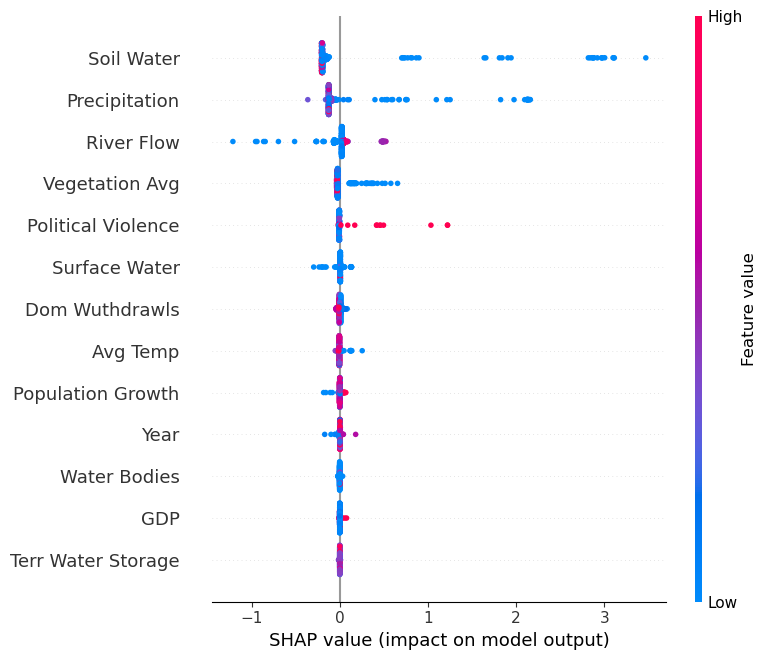

In [39]:
train_all = ws2[ws2["Year"] < 2016].dropna(subset=[target])
X_train_all = train_all[features]
y_train_all = train_all[target]

xgb.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all)

## Avoiding Leakage

In [40]:
ws3 = ws_df.copy()

ws3["WS_custom"] = (
    ws3["Overall Water Withdrawals"] /
    ws3["Freshwater Resources"]
)

ws3["WS_custom_log"] = np.log1p(ws3["WS_custom"])
target = "WS_custom_log"

ws3 = ws3.drop(columns=["Water Stress"], errors="ignore")

In [41]:
forbidden = [
    "WS_custom", "WS_custom_log",
    "Overall Water Withdrawals", "Freshwater Resources",

    "Dom Withdrawals", "Domestic Withdrawals",
    "Ind Withdrawals", "Agr Withdrawals",
    "Total Withdrawals",

    "Precipitation", "River Flow", "Soil Water",
    "Surface Water", "Terr Water Storage",
    "Water Bodies", "Vegetation Avg", "Avg Temp",

    "GDP", "Population Growth",

    "Year"
]

In [42]:
features = [
    col for col in ws3.columns
    if col not in forbidden and ws3[col].dtype != "object"
]

print("Final leakage-free features:", features)


Final leakage-free features: ['Dom Wuthdrawls', 'Political Violence']


In [43]:
train = ws3[ws3["Year"] < 2016].dropna(subset=[target])
test  = ws3[ws3["Year"] == 2016].dropna(subset=[target])

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (409, 2) Test shape: (29, 2)


In [44]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Leakage-free XGB R2:", r2_score(y_test, y_pred))

Leakage-free XGB R2: -0.008836866877266258


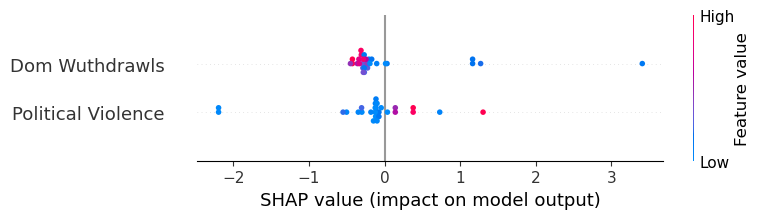

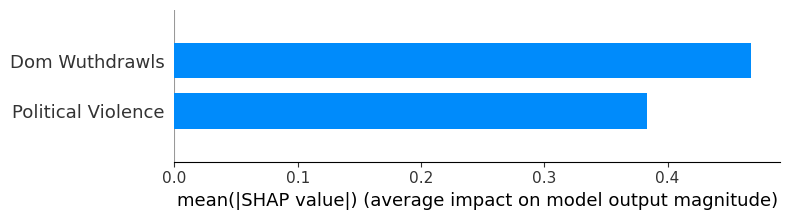

In [45]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [46]:
years = [2016, 2017, 2018]
scores = []

for test_year in years:
    train_df = ws3[ws3["Year"] < test_year].dropna(subset=[target])
    test_df  = ws3[ws3["Year"] == test_year].dropna(subset=[target])

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores.append(score)
    print(f"Year {test_year}: R2 = {score:.3f}")

print("Average leakage-free R2:", np.mean(scores))


Year 2016: R2 = -0.009
Year 2017: R2 = -0.405
Year 2018: R2 = 0.464
Average leakage-free R2: 0.016536699462675813


## Creating a Drought Index

In [47]:
from sklearn.preprocessing import StandardScaler
di = ws_df.copy()

drought_core = ["Avg Temp", "Precipitation", "Soil Water", "Vegetation Avg"]

scaler_A = StandardScaler()
di[[f"z_{v}" for v in drought_core]] = scaler_A.fit_transform(di[drought_core])

di["DI_A"] = (
    di["z_Avg Temp"]
    - di["z_Precipitation"]
    - di["z_Soil Water"]
    - di["z_Vegetation Avg"]
)

target = "DI_A"

forbidden = [
    "DI_A",
    "z_Avg Temp", "z_Precipitation", "z_Soil Water", "z_Vegetation Avg",
    "Avg Temp", "Precipitation", "Soil Water", "Vegetation Avg"
]
features = [
    c for c in di.columns
    if c not in forbidden and di[c].dtype != "object"
]

In [48]:
results = []
years = sorted(di["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = di[di["Year"] < test_year].dropna(subset=[target])
    test  = di[di["Year"] == test_year].dropna(subset=[target])

    if len(test) == 0:
        continue

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    reg = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    reg.fit(X_train, y_train)
    preds = reg.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year      RMSE        R2
0        2006  0.779419  0.903743
1        2007  0.516389  0.958787
2        2008  0.434673  0.968053
3        2009  0.562654  0.947691
4        2010  0.879173  0.872625
5        2011  1.046609  0.831301
6        2012  0.882599  0.869125
7        2013  0.634797  0.932785
8        2014  0.459142  0.965381
9        2015  0.439939  0.967785
10       2016  0.392557  0.972235
11       2017  0.676160  0.924857
12       2018  0.436450  0.969833
13       2019  0.502643  0.959403
14       2020  0.373084  0.975836


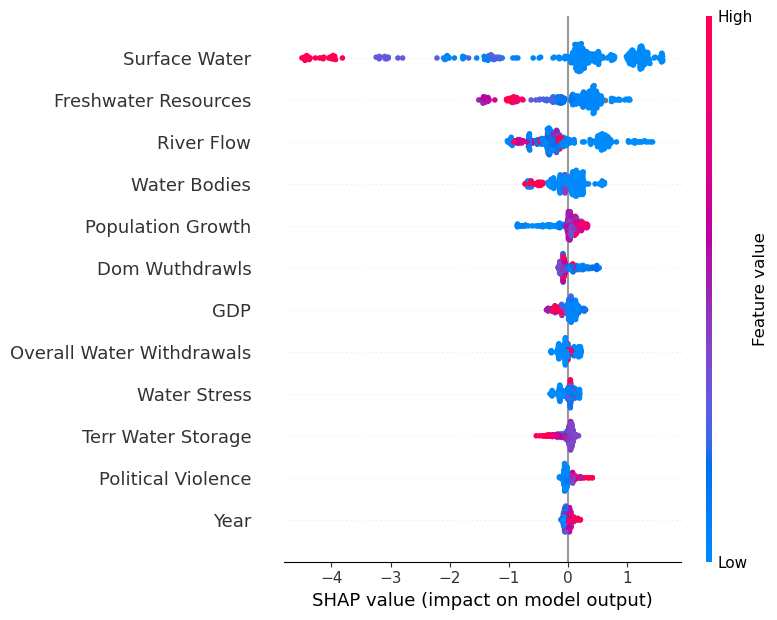

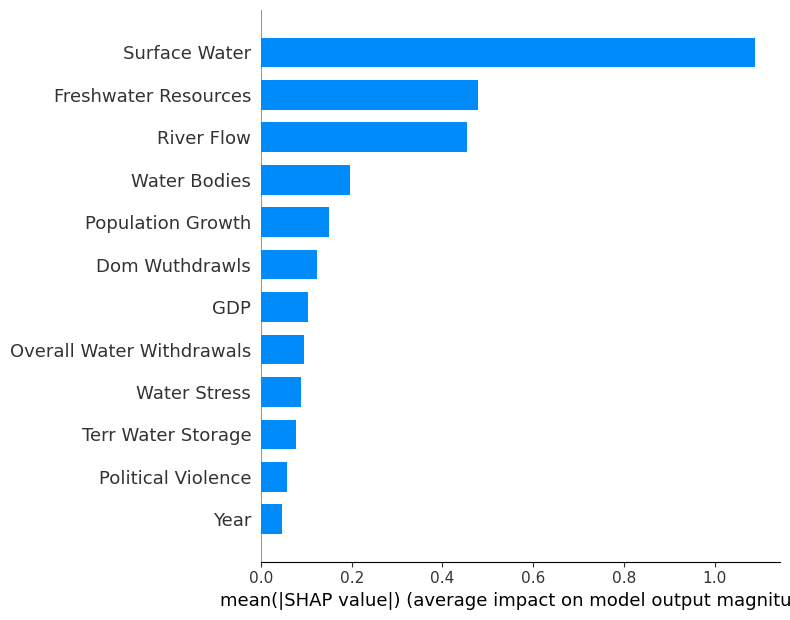

In [49]:
train_all = di[di["Year"] < 2016].dropna(subset=[target])
X_train_all = train_all[features]
y_train_all = train_all[target]

reg.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all)
shap.summary_plot(shap_values, X_train_all, plot_type="bar")

## Changing Target to Population Growth

XGBoost

In [50]:
pg = ws_df.copy()

pg = pg.sort_values(["Country", "Year"])
pg["PopGrowth_delta"] = pg.groupby("Country")["Population Growth"].diff()

target = "Population Growth"

hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Water Bodies",
    "Vegetation Avg",
    "Avg Temp",
    "Freshwater Resources",
    "Water Stress",
    "Year"
]

In [51]:
features = [f for f in hydro_features if f in pg.columns]

# 3. Drop rows missing the target
pg_model = pg.dropna(subset=[target])

# 4. Train/test split (fixed 2016 for this exploratory section)
train = pg_model[pg_model["Year"] < 2016]
test  = pg_model[pg_model["Year"] == 2016]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [52]:
reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print("Population Growth R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)


Population Growth R2: 0.7614308149682218
RMSE: 0.5488014718881392


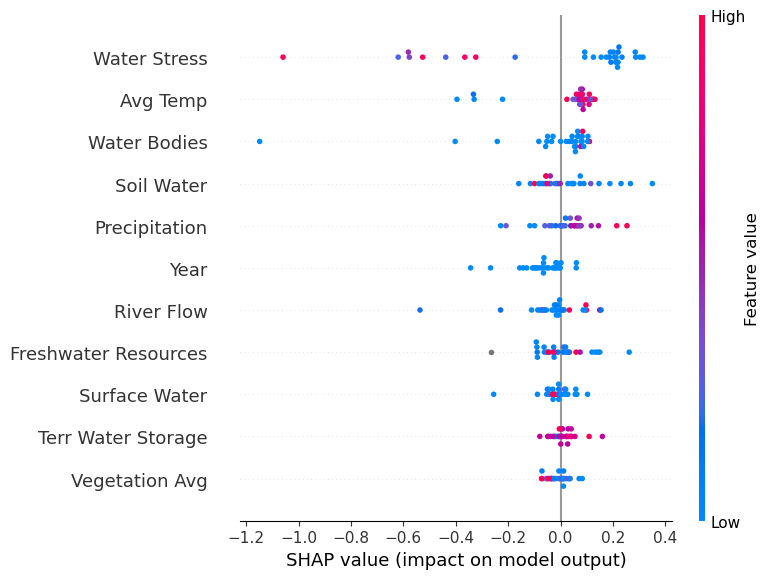

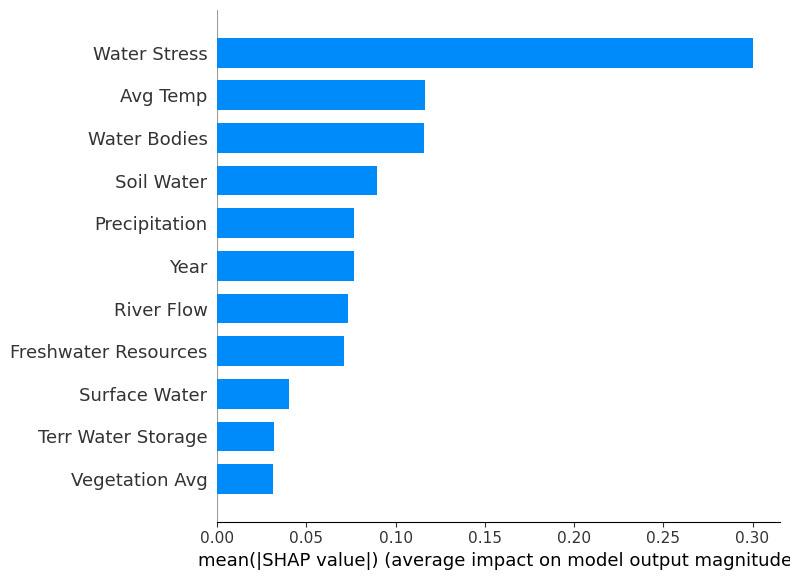

In [53]:
explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")


##Removing Water Stress + Hydro Features Only

XGBoost

In [54]:
hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Water Bodies",
    "Vegetation Avg",
    "Avg Temp",
    "Freshwater Resources",
    "Year"
]


In [55]:
pg = ws_df.copy()

target = "Population Growth"

hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Water Bodies",
    "Vegetation Avg",
    "Avg Temp",
    "Freshwater Resources",
    "Year"
]

pg = pg.dropna(subset=[target])

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

results = []
years = sorted(pg["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    if len(test) == 0:
        continue

    X_train = train[hydro_features]
    y_train = train[target]

    X_test = test[hydro_features]
    y_test = test[target]

    model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results.append({
        "Test Year": test_year,
        "R2": r2,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
print(results_df)

print("Average XGBoost R²:", results_df["R2"].mean())



    Test Year        R2      RMSE
0        2006  0.796042  0.423220
1        2007  0.898284  0.272322
2        2008  0.803410  0.340302
3        2009  0.789806  0.322002
4        2010  0.840405  0.267907
5        2011  0.427322  0.877328
6        2012  0.452967  0.854627
7        2013 -0.233634  0.686191
8        2014  0.254508  0.602485
9        2015  0.249581  0.775807
10       2016  0.810473  0.489152
11       2017  0.699554  0.387385
12       2018  0.876569  0.220993
13       2019  0.791610  0.277427
14       2020  0.906784  0.183453
Average XGBoost R²: 0.6242454584802145


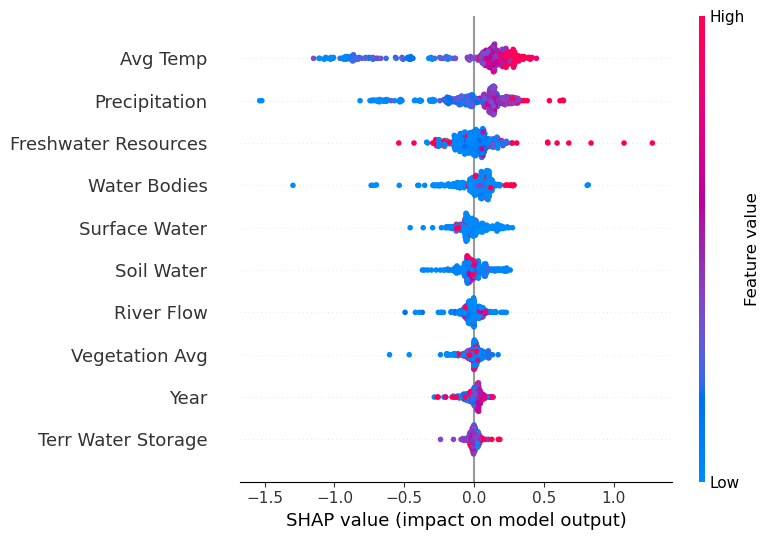

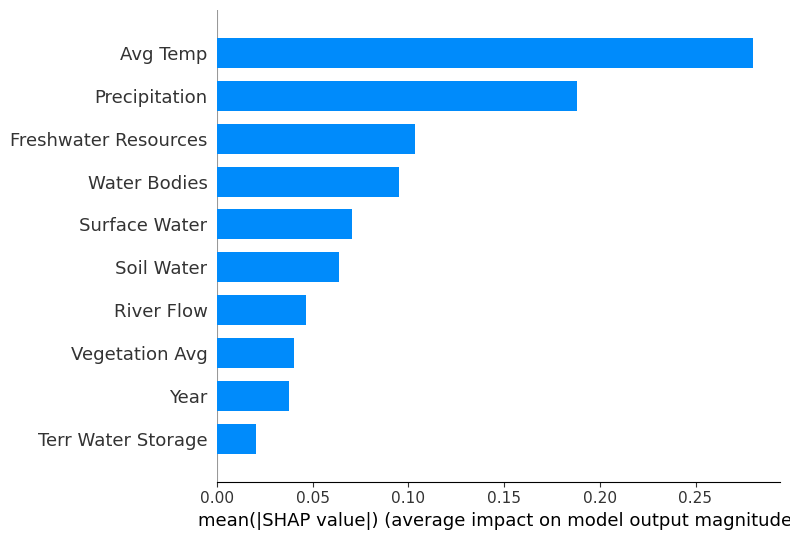

In [56]:
train_all = pg[pg["Year"] < 2016]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all)

shap.summary_plot(shap_values, X_train_all, plot_type="bar")


Other Models

In [57]:
pg = ws_df.copy()
target = "Population Growth"

hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Water Bodies",
    "Vegetation Avg",
    "Avg Temp",
    "Freshwater Resources",
    "Year"
]

pg = pg.dropna(subset=[target])

years = sorted(pg["Year"].unique())

##Linear Regression (Baseline)

In [58]:
from sklearn.linear_model import LinearRegression

lin_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    lin_scores.append(r2_score(y_test, preds))

print("Linear Regression average R²:", np.mean(lin_scores))


Linear Regression average R²: 0.19854626114154855


##Ridge Regression

In [60]:
from sklearn.linear_model import Ridge

ridge_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    # Ridge cannot handle NaNs → drop rows
    X_train_ridge = train[hydro_features].dropna()
    y_train_ridge = train.loc[X_train_ridge.index, target]

    X_test_ridge = test[hydro_features].dropna()
    y_test_ridge = test.loc[X_test_ridge.index, target]

    model = Ridge(alpha=1.0)
    model.fit(X_train_ridge, y_train_ridge)

    preds = model.predict(X_test_ridge)
    ridge_scores.append(r2_score(y_test_ridge, preds))

print("Ridge Regression average R²:", np.mean(ridge_scores))

Ridge Regression average R²: 0.19588279097217118


C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.01835e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.76827e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.46052e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.24664e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.0893e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Use

##Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rf_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features]
    y_train = train[target]

    X_test = test[hydro_features]
    y_test = test[target]

    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rf_scores.append(r2_score(y_test, preds))

print("Random Forest average R²:", np.mean(rf_scores))


Random Forest average R²: 0.5826552307096127


SHAP Random Forest and XGBoost

Random Forest

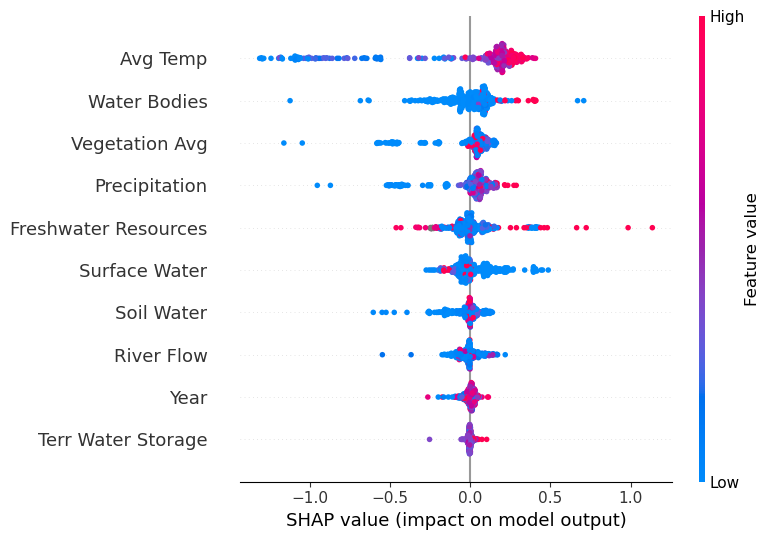

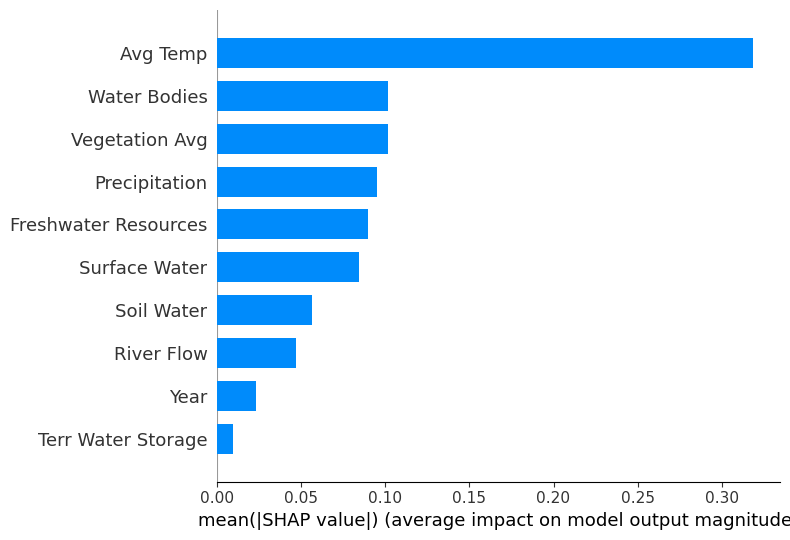

In [62]:
train_all = pg[pg["Year"] < 2016]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42
)

rf.fit(X_train_all, y_train_all)

expl_rf = shap.TreeExplainer(rf)
shap_rf = expl_rf.shap_values(X_train_all)

shap.summary_plot(shap_rf, X_train_all)
shap.summary_plot(shap_rf, X_train_all, plot_type="bar")

XGBoost

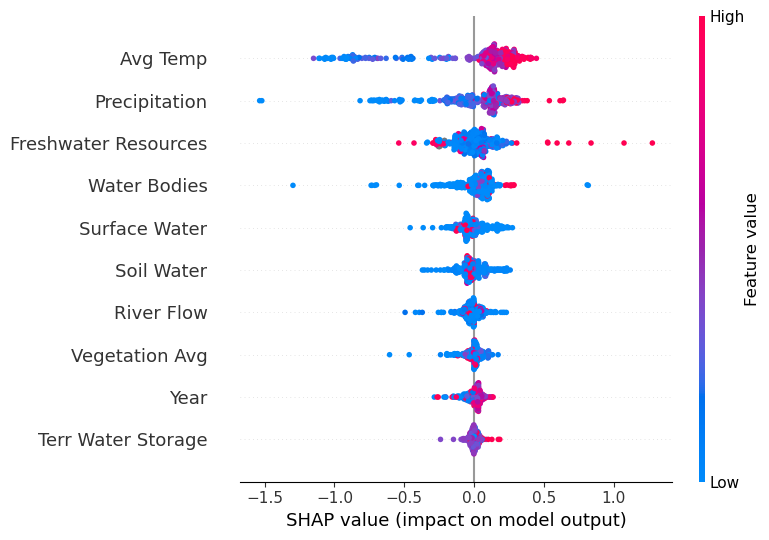

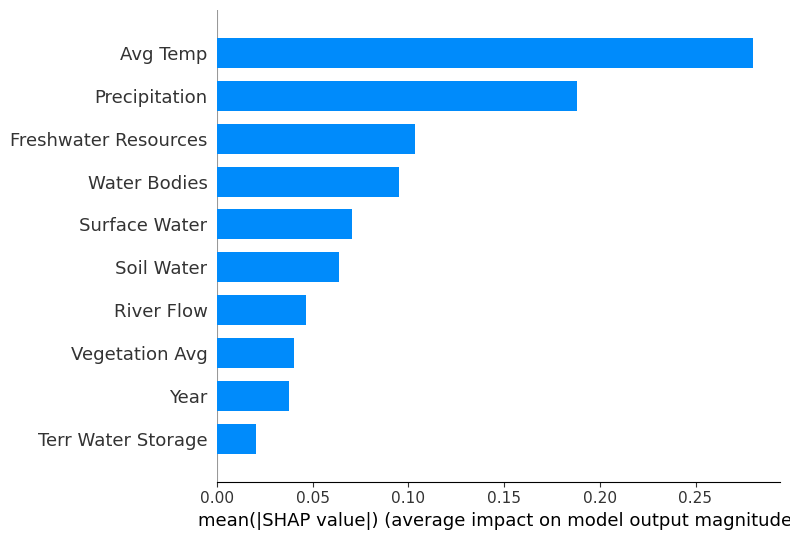

In [63]:
xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train_all, y_train_all)

expl_xgb = shap.TreeExplainer(xgb)
shap_xgb = expl_xgb.shap_values(X_train_all)

shap.summary_plot(shap_xgb, X_train_all)
shap.summary_plot(shap_xgb, X_train_all, plot_type="bar")


Coefficients for Linear and Ridge

In [64]:
train_all = pg[pg["Year"] < 2016]

X_train_all = train_all[hydro_features].dropna()
y_train_all = train_all.loc[X_train_all.index, target]

ridge_final = Ridge(alpha=1.0)
ridge_final.fit(X_train_all, y_train_all)

lin_final = LinearRegression()
lin_final.fit(X_train_all, y_train_all)


C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.50951e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
coef_df = pd.DataFrame({
    "feature": hydro_features,
    "coef_linear": lin_final.coef_,
    "coef_ridge": ridge_final.coef_
}).sort_values("coef_ridge", key=abs, ascending=False)

coef_df


,feature,coef_linear,coef_ridge
2,Surface Water,8.981120e-01,4.309115e-01
7,Avg Temp,1.023600e-01,1.008117e-01
1,Soil Water,-1.002950e-01,-8.274403e-02
9,Year,-4.195883e-03,-4.663175e-03
0,Precipitation,5.935683e-04,6.132388e-04
4,Terr Water Storage,5.845469e-06,3.604081e-05
6,Vegetation Avg,-1.644945e-03,-2.848317e-05
8,Freshwater Resources,-1.623413e-05,-1.725110e-05
3,River Flow,1.654221e-05,1.635602e-05
5,Water Bodies,-1.726025e-08,-6.290747e-09


## LightGBM

In [66]:
!pip install lightgbm


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.9 MB/s  0:00:00


In [67]:
import lightgbm as lgb


In [68]:
lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


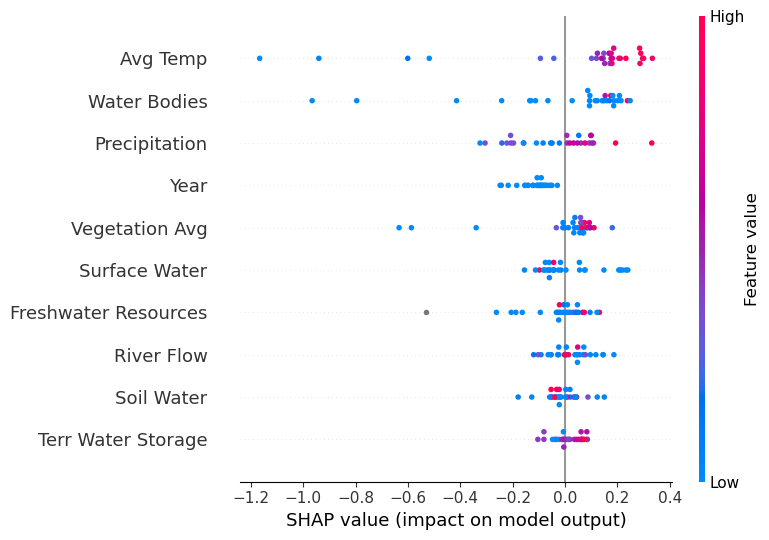

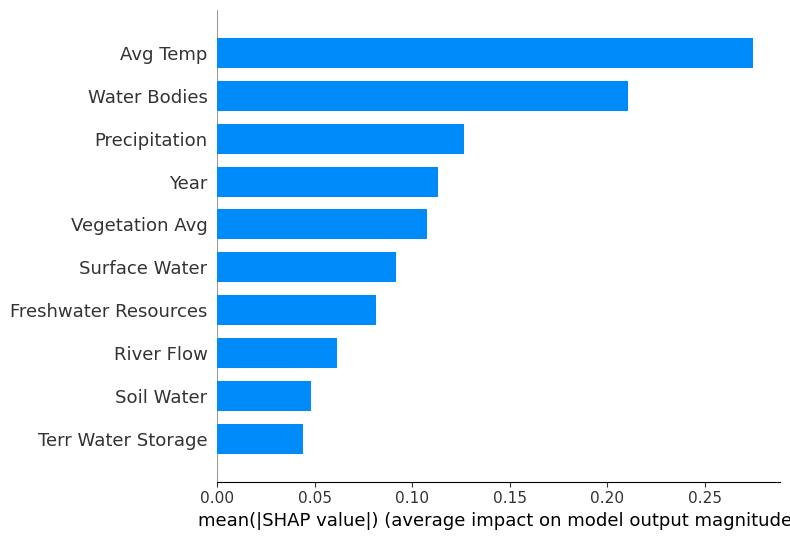

In [70]:
import shap

expl_lgbm = shap.TreeExplainer(lgbm)
shap_lgbm = expl_lgbm.shap_values(X_test)

shap.summary_plot(shap_lgbm, X_test)
shap.summary_plot(shap_lgbm, X_test, plot_type="bar")


## LightGBM Using Only Hydrological Features

In [78]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lgb_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features]
    y_train = train[target]

    X_test = test[hydro_features]
    y_test = test[target]

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    lgb_scores.append(r2_score(y_test, preds))

print("LightGBM average R²:", np.mean(lgb_scores))


KeyError: "['Dom Withdrawals', 'Industrial Withdrawals', 'Agricultural Withdrawals'] not in index"

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1265
[LightGBM] [Info] Number of data points in the train set: 424, number of used features: 10
[LightGBM] [Info] Start training from score 2.574524
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

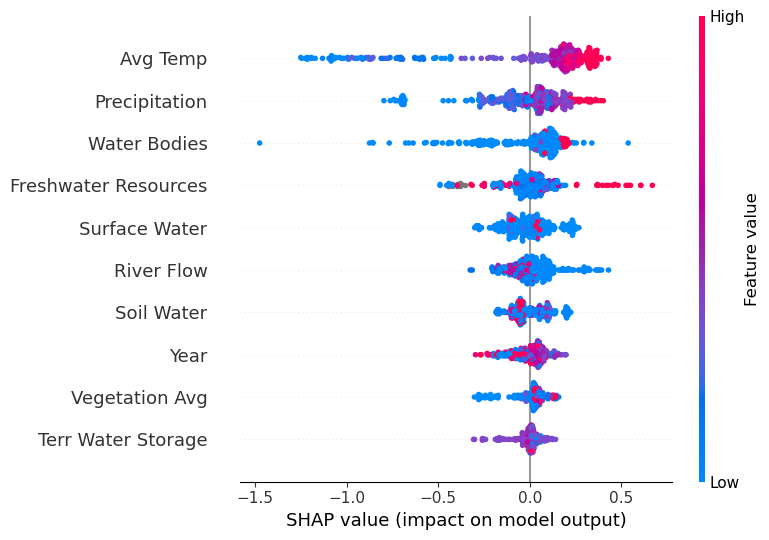

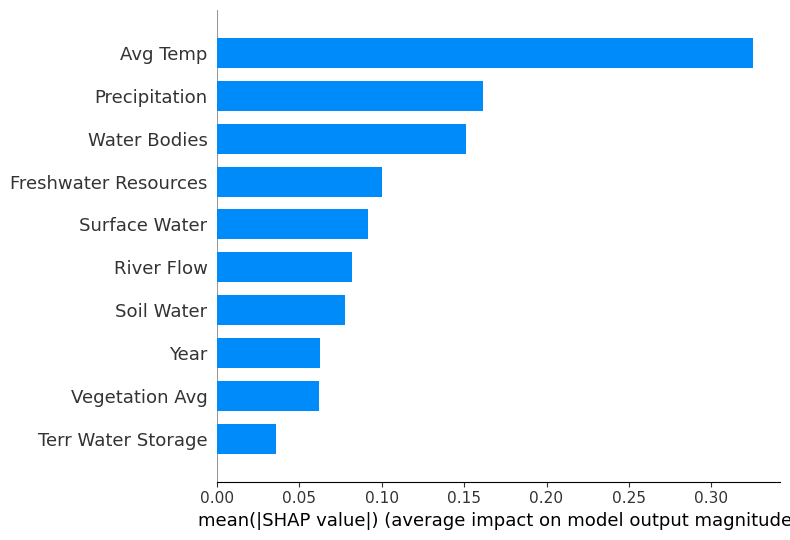

In [72]:
# Fit on all pre-2016 data
train_all = pg[pg["Year"] < 2016]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

lgbm_final = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_final.fit(X_train_all, y_train_all)

expl_lgbm = shap.TreeExplainer(lgbm_final)
shap_lgbm = expl_lgbm.shap_values(X_train_all)

shap.summary_plot(shap_lgbm, X_train_all)
shap.summary_plot(shap_lgbm, X_train_all, plot_type="bar")


In [74]:
hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Vegetation Avg",
    "Water Bodies",
    "Avg Temp",
    "Freshwater Resources",
    "Overall Water Withdrawals",
    "Dom Withdrawals",
    "Industrial Withdrawals",
    "Agricultural Withdrawals"
]

hydro_features = [f for f in hydro_features if f in df_clean2.columns]


NameError: name 'df_clean2' is not defined

In [75]:
train = df_clean2[df_clean2["Year"] < 2016].dropna(subset=["Population Growth"])
test  = df_clean2[df_clean2["Year"] == 2016].dropna(subset=["Population Growth"])

X_train = train[hydro_features]
y_train = train["Population Growth"]
X_test  = test[hydro_features]
y_test  = test["Population Growth"]


NameError: name 'df_clean2' is not defined

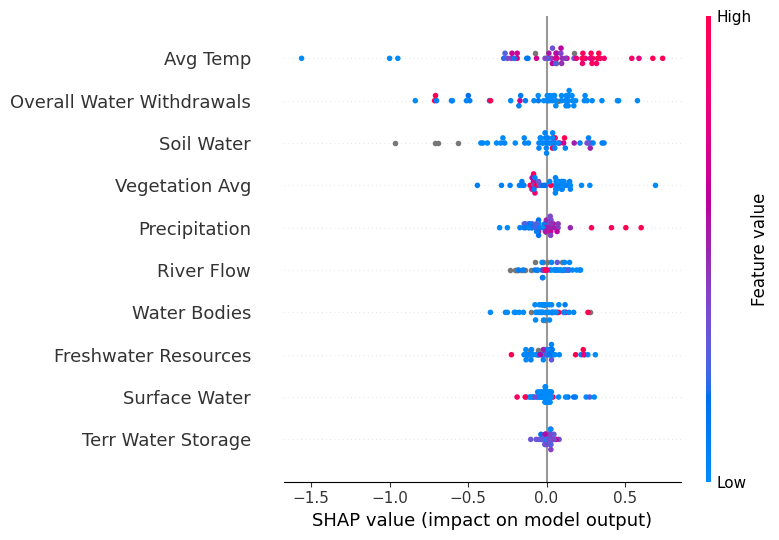

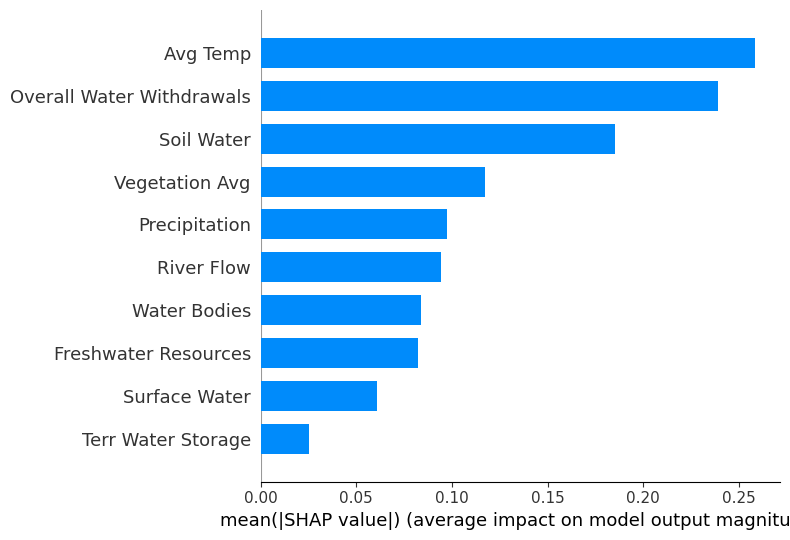

In [ ]:
import shap

expl_lgbm = shap.TreeExplainer(lgbm)
shap_lgbm = expl_lgbm.shap_values(X_test)

shap.summary_plot(shap_lgbm, X_test)
shap.summary_plot(shap_lgbm, X_test, plot_type="bar")


## Cross Validation